In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [27]:
# Ideal sims results
ideal_rf_file = "/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/uniform_50cells_50sites_0.0025mut_10-6mig_data_8_24_24/tree_reconstruction_accuracy/all_tree_reconstruction_accuracy.csv"
ideal_rf_df = pd.read_csv(ideal_rf_file)

ideal_rf_df

,simname,laml_rf,laml_normalized_rf,laml_is_true_tree,cassiopeia_rf,cassiopeia_normalized_rf,cassiopeia_is_true_tree,beam_posterior_rf,beam_posterior_normalized_rf,beam_contains_true_tree,pathfinder_rf,pathfinder_normalized_rf,pathfinder_is_true_tree,random_rf,random_normalized_rf,random_is_true_tree
0,22396,48,0.510638,False,48,0.510638,False,48.142857,0.512143,False,56,0.595745,False,94,0.989474,False
1,7277,64,0.666667,False,66,0.687500,False,60.954023,0.635975,False,56,0.583333,False,96,1.000000,False
2,26925,50,0.520833,False,50,0.520833,False,51.859606,0.541520,False,56,0.589474,False,96,1.000000,False
3,22265,54,0.562500,False,54,0.562500,False,42.147783,0.439934,False,54,0.568421,False,96,1.000000,False
4,21766,48,0.500000,False,52,0.541667,False,49.029557,0.511183,False,56,0.583333,False,94,0.979167,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9226,44,0.458333,False,42,0.437500,False,36.454844,0.379923,False,40,0.416667,False,96,1.000000,False
96,28350,52,0.541667,False,50,0.520833,False,39.500821,0.412784,False,38,0.395833,False,96,1.000000,False
97,23324,44,0.463158,False,44,0.463158,False,44.993432,0.475346,False,58,0.610526,False,96,1.010526,False
98,12050,54,0.562500,False,52,0.541667,False,48.287356,0.503007,False,50,0.520833,False,96,1.000000,False


In [28]:
# Reshape to long format for seaborn
rf_long = pd.melt(
    ideal_rf_df,
    id_vars=["simname"],
    value_vars=[
        "laml_normalized_rf",
        "cassiopeia_normalized_rf",
        "beam_posterior_normalized_rf",
        "random_normalized_rf",
        "pathfinder_normalized_rf",
    ],
    var_name="Method",
    value_name="Normalized_RF"
)

# Clean method names for plotting
rf_long["Method"] = rf_long["Method"].replace({
    "laml_normalized_rf": "LAML",
    "cassiopeia_normalized_rf": "Cassiopeia-greedy",
    "beam_posterior_normalized_rf": "BEAM",
    "pathfinder_normalized_rf": "PathFinder-NJ",
    "random_normalized_rf": "Random",
})

# Create a DataFrame with same simnames and zeros for the "True Tree" category for visual reference
true_tree_df = pd.DataFrame({
    "simname": rf_long["simname"].unique(),
    "Method": "True tree",
    "Normalized_RF": 0.0
})

rf_long = pd.concat([rf_long, true_tree_df], ignore_index=True)

# Remove some methods
methods_to_remove = ["Random", "True tree", "PathFinder-NJ"]
rf_long = rf_long[~rf_long["Method"].isin(methods_to_remove)]

all_methods = ["True tree", "BEAM", "LAML", "Cassiopeia-greedy", "Random"]
methods_order = [method for method in all_methods if method not in methods_to_remove]


# Order for plotting
rf_long["Method"] = pd.Categorical(
    rf_long["Method"],
    categories=methods_order,
    ordered=True
)


rf_long

,simname,Method,Normalized_RF
0,22396,LAML,0.510638
1,7277,LAML,0.666667
2,26925,LAML,0.520833
3,22265,LAML,0.562500
4,21766,LAML,0.500000
...,...,...,...
295,9226,BEAM,0.379923
296,28350,BEAM,0.412784
297,23324,BEAM,0.475346
298,12050,BEAM,0.503007


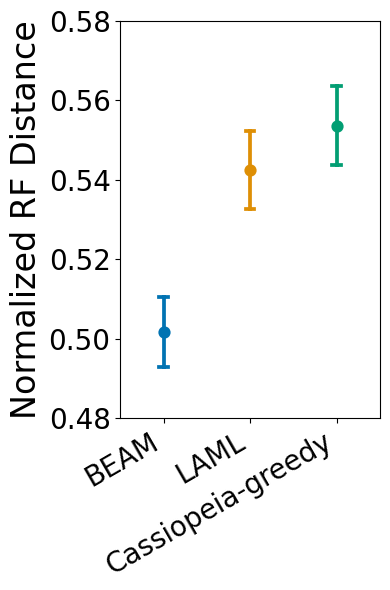

In [34]:

plt.figure(figsize=(4, 6))
fs=24

# sns.boxplot(
#     data=rf_long,
#     x="Method",
#     y="Normalized_RF",
#     hue="Method",
#     palette="colorblind",
#     legend=False,
#     fliersize=0
# )

# sns.stripplot(
#     data=rf_long,
#     x="Method",
#     y="Normalized_RF",
#     color="black",
#     size=6,
#     alpha=0.5,
#     jitter=True,
# )

sns.pointplot(
    data=rf_long,
    x="Method",
    y="Normalized_RF",
    hue="Method",
    palette="colorblind",
    errorbar="se",
    capsize=0.1
)

plt.title("", fontsize=fs)
plt.ylabel("Normalized RF Distance", fontsize=fs)
plt.xlabel("", fontsize=fs)
plt.xticks(fontsize=fs-4, rotation=30, ha='right')
plt.yticks(fontsize=fs-4)
# plt.ylim(-0.05, 1.05)
plt.ylim(0.48, 0.58)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.02))
plt.tight_layout()
plt.show()
# plt.savefig(ideal_rf_file.replace(".csv", ".pdf"))
plt.close()

In [67]:
# Variable sims results
variable_rf_file = "/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/variable_migration_and_mutation_rates_data_8_19_24/tree_reconstruction_accuracy/all_tree_reconstruction_accuracy.csv"
variable_rf_df = pd.read_csv(variable_rf_file)

cols_to_keep = [col for col in variable_rf_df.columns if "random" not in col]
variable_rf_df = variable_rf_df[cols_to_keep]

variable_rf_df

,simname,laml_rf,laml_normalized_rf,laml_is_true_tree,cassiopeia_rf,cassiopeia_normalized_rf,cassiopeia_is_true_tree,beam_posterior_rf,beam_posterior_normalized_rf,beam_contains_true_tree,pathfinder_rf,pathfinder_normalized_rf,pathfinder_is_true_tree
0,mig4_mut0025_2528,46,0.479167,False,46,0.479167,False,44.717213,0.467264,False,48,0.500000,False
1,mig6_mut0025_1983,52,0.541667,False,50,0.520833,False,47.180328,0.491781,False,38,0.395833,False
2,mig5_mut0025_4262,38,0.400000,False,48,0.500000,False,43.374384,0.452634,False,42,0.437500,False
3,mig6_mut0005_31114,68,0.708333,False,68,0.708333,False,65.960591,0.688545,False,62,0.652632,False
4,mig6_mut01_32163,24,0.250000,False,24,0.250000,False,25.702791,0.267737,False,20,0.208333,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,mig7_mut01_10788,70,0.729167,False,66,0.687500,False,67.586207,0.704023,False,72,0.750000,False
396,mig5_mut005_6169,40,0.416667,False,40,0.416667,False,25.213115,0.262675,False,26,0.270833,False
397,mig6_mut0005_10026,86,0.895833,False,86,0.895833,False,83.609195,0.872965,False,84,0.884211,False
398,mig5_mut0025_983,36,0.375000,False,42,0.437500,False,43.581967,0.453979,False,46,0.479167,False


In [68]:
def parse_var_category(var_rates_category):
    """
    Converts strings like 'mig5_mut0025' → migration=1e-5, mutation=0.0025
    """
    mig_rate = 10**-float(var_rates_category.split("_")[0].replace("mig", ""))
    mut_rate = float("0." + str(var_rates_category.split("_")[1].replace("mut", "")))
    return mig_rate, mut_rate

In [69]:
variable_rf_df['var_rates_category'] = variable_rf_df['simname'].apply(
    lambda x: "_".join(x.split("_")[0:2])
)
variable_rf_df[["migration_rate", "mutation_rate"]] = variable_rf_df["var_rates_category"].apply(
    lambda x: pd.Series(parse_var_category(x))
)
variable_rf_df

,simname,laml_rf,laml_normalized_rf,laml_is_true_tree,cassiopeia_rf,cassiopeia_normalized_rf,cassiopeia_is_true_tree,beam_posterior_rf,beam_posterior_normalized_rf,beam_contains_true_tree,pathfinder_rf,pathfinder_normalized_rf,pathfinder_is_true_tree,var_rates_category,migration_rate,mutation_rate
0,mig4_mut0025_2528,46,0.479167,False,46,0.479167,False,44.717213,0.467264,False,48,0.500000,False,mig4_mut0025,1.000000e-04,0.0025
1,mig6_mut0025_1983,52,0.541667,False,50,0.520833,False,47.180328,0.491781,False,38,0.395833,False,mig6_mut0025,1.000000e-06,0.0025
2,mig5_mut0025_4262,38,0.400000,False,48,0.500000,False,43.374384,0.452634,False,42,0.437500,False,mig5_mut0025,1.000000e-05,0.0025
3,mig6_mut0005_31114,68,0.708333,False,68,0.708333,False,65.960591,0.688545,False,62,0.652632,False,mig6_mut0005,1.000000e-06,0.0005
4,mig6_mut01_32163,24,0.250000,False,24,0.250000,False,25.702791,0.267737,False,20,0.208333,False,mig6_mut01,1.000000e-06,0.0100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,mig7_mut01_10788,70,0.729167,False,66,0.687500,False,67.586207,0.704023,False,72,0.750000,False,mig7_mut01,1.000000e-07,0.0100
396,mig5_mut005_6169,40,0.416667,False,40,0.416667,False,25.213115,0.262675,False,26,0.270833,False,mig5_mut005,1.000000e-05,0.0050
397,mig6_mut0005_10026,86,0.895833,False,86,0.895833,False,83.609195,0.872965,False,84,0.884211,False,mig6_mut0005,1.000000e-06,0.0005
398,mig5_mut0025_983,36,0.375000,False,42,0.437500,False,43.581967,0.453979,False,46,0.479167,False,mig5_mut0025,1.000000e-05,0.0025


In [9]:
# Reshape to long format for seaborn
variable_rf_long = pd.melt(
    variable_rf_df,
    id_vars=["simname", "migration_rate", "mutation_rate"],
    value_vars=[
        "laml_normalized_rf",
        "cassiopeia_normalized_rf",
        "beam_posterior_normalized_rf",
        "pathfinder_normalized_rf"
    ],
    var_name="Method",
    value_name="Normalized_RF"
)

# Clean method names for plotting
variable_rf_long["Method"] = variable_rf_long["Method"].replace({
    "laml_normalized_rf": "LAML",
    "cassiopeia_normalized_rf": "Cassiopeia-greedy",
    "beam_posterior_normalized_rf": "BEAM",
    "pathfinder_normalized_rf": "PathFinder-NJ",
})

variable_rf_long["Method"] = pd.Categorical(
    variable_rf_long["Method"],
    categories=["BEAM", "LAML", "Cassiopeia-greedy", "PathFinder-NJ"],
    ordered=True
)

variable_rf_long

NameError: name 'variable_rf_df' is not defined

/tmp/ipykernel_2266860/3596900702.py:3: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  g = sns.catplot(


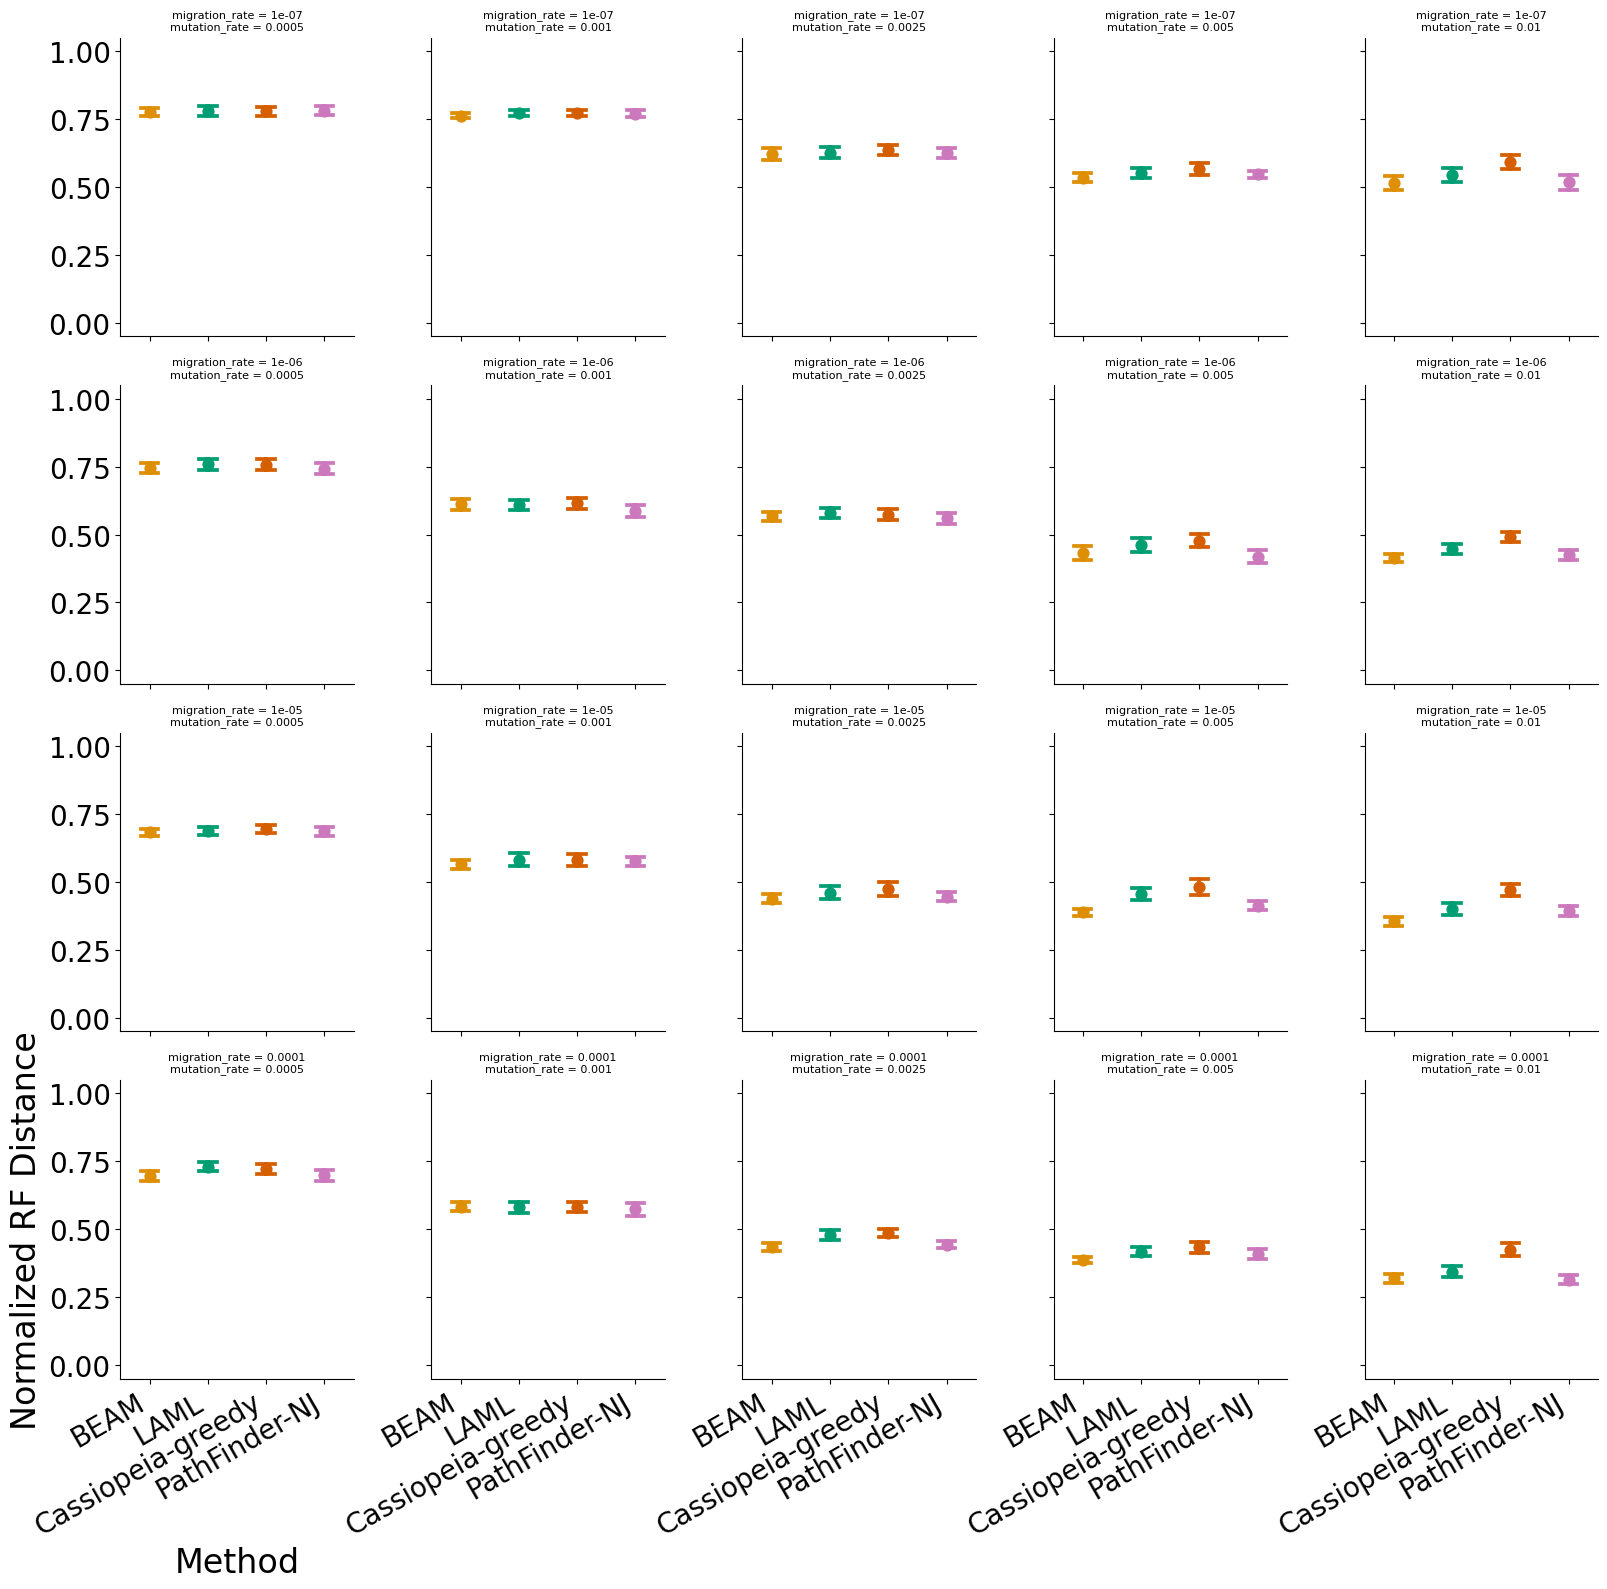

In [ ]:
fs = 24

g = sns.catplot(
    data=variable_rf_long,
    x="Method",
    y="Normalized_RF",
    hue="Method",
    row="migration_rate",
    col="mutation_rate",
    palette = sns.color_palette("colorblind")[1:],
    kind="point",
    errorbar='se',
    capsize=0.3,
    sharey=True,
    sharex=True,
    legend=False,
    height = 4,
    aspect = 0.8
)

# for i, row_val in enumerate(g.row_names):
#     for j, col_val in enumerate(g.col_names):
#         ax = g.axes[i, j]
#         subset = variable_rf_long[
#             (variable_rf_long["migration_rate"] == row_val) &
#             (variable_rf_long["mutation_rate"] == col_val)
#         ]
#         sns.stripplot(
#             data=subset,
#             x="Method",
#             y="Normalized_RF",
#             color="black",     # match your single-plot style
#             alpha=0.6,
#             size=6,
#             jitter=True,
#             ax=ax,
#             legend=False
#         )

n_rows, n_cols = g.axes.shape
ax_bottom_left = g.axes[-1, 0]
ax_bottom_left.set_xlabel("Method", fontsize=fs)
ax_bottom_left.set_ylabel("Normalized RF Distance", fontsize=fs)

for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if not (i == n_rows - 1 and j == 0):
            ax.set_xlabel("")
            ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=fs - 4, rotation=30)
        ax.tick_params(axis="y", labelsize=fs - 4)
        for label in ax.get_xticklabels():
            label.set_ha('right')

for ax in g.axes.flatten():
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(ax.get_title().replace(" | ", "\n"), fontsize=8)

plt.tight_layout()
plt.show()
# plt.savefig(variable_rf_file.replace(".csv", ".pdf"))
plt.close()
